In [1]:
# process_cdm_results.py
import os
import json
import pandas as pd
import glob
import re
# from openai import OpenAI # Required to execute Task 2 in this script.

# --- 1. Global configuration ---

# a. Define file and directory paths
# Root directory containing run_1, run_2, ... folders
# BASE_RESULTS_DIR = '/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/evaluation_logs/55_clean' 
BASE_RESULTS_DIR = '/mnt/bulk-uranus/lizhang/LiWorkSpace/data/evaluation/85/fuzzy_matching' 
# Directory for the final CSV and other outputs
OUTPUT_DIR = os.path.join(BASE_RESULTS_DIR, "cdm")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# b. Define dataset and category mappings
DATASET_TO_CATEGORY = {
    "appendicitis": "Appendicitis",
    "cholecystitis": "Cholecystitis",
    "diverticulitis": "Diverticulitis",
    "pancreatitis": "Pancreatitis",
}
ALL_DATASETS_INTERNAL = list(DATASET_TO_CATEGORY.keys())

In [2]:
# --- 2. Task 1: calculate and save accuracy ---

def calculate_and_save_accuracies():
    """
    遍历所有运行结果，计算准确率，并保存到一个CSV文件中。
    同时，收集所有错误案例以备后续分析。
    """
    all_runs_raw_data = []
    
    # Use glob to find all run_* directories
    run_dirs = sorted(glob.glob(os.path.join(BASE_RESULTS_DIR, 'run_*')))
    
    print(f"📂 Found {len(run_dirs)} run directories to process.")

    for run_dir in run_dirs:
        # Extract run_id from the directory path
        try:
            run_id = int(re.search(r'run_(\d+)', run_dir).group(1))
        except (AttributeError, ValueError):
            print(f"  警告: 无法从目录名 {run_dir} 提取 run_id，已跳过。")
            continue
            
        print(f"\n--- Processing Run ID: {run_id} ---")
        
        # Find all ..._fuzzy.jsonl files in each run directory
        fuzzy_files = glob.glob(os.path.join(run_dir, '**', '*_diagnosis_results_fuzzy.jsonl'), recursive=True)
        
        for file_path in fuzzy_files:
            # Extract the dataset name from the filename
            filename = os.path.basename(file_path)
            dataset_name_match = re.search(r'(\w+)_diagnosis_results_fuzzy.jsonl', filename)
            if not dataset_name_match:
                continue
            
            dataset_name = dataset_name_match.group(1)
            
            if dataset_name not in ALL_DATASETS_INTERNAL:
                continue

            # Read and process the file
            try:
                df = pd.read_json(file_path, lines=True)
                
                # Ensure the score column exists
                if 'gracious_diagnosis_score' not in df.columns:
                    print(f"    警告: 文件 {file_path} 中缺少 'gracious_diagnosis_score' 列，已跳过。")
                    continue
                
                # --- Core change 1: collect raw data rather than computed accuracy ---
                df['dataset'] = DATASET_TO_CATEGORY[dataset_name]
                df['run_id'] = run_id
                all_runs_raw_data.append(df[['dataset', 'run_id', 'gracious_diagnosis_score']])

            except Exception as e:
                print(f"  ❌ 错误: 处理文件 {file_path} 时出错: {e}")

    if not all_runs_raw_data:
        print("❌ 错误: 未能加载任何数据。")
        return

    # a. Combine all raw data into one large DataFrame
    df_all_runs = pd.concat(all_runs_raw_data, ignore_index=True)
    
    # b. Calculate accuracy for each individual dataset
    # Group by dataset and run_id, then calculate mean gracious_diagnosis_score
    df_accuracies_per_dataset = df_all_runs.groupby(['dataset', 'run_id'])['gracious_diagnosis_score'].mean().reset_index()
    df_accuracies_per_dataset['accuracy'] = df_accuracies_per_dataset['gracious_diagnosis_score'] * 100
    df_accuracies_per_dataset.drop(columns=['gracious_diagnosis_score'], inplace=True)
    
    print("\n--- 每个独立数据集的准确率 ---")
    print(df_accuracies_per_dataset.head())

    # c. Calculate Overall accuracy (the correct weighting method)
    # Group by run_id, then average gracious_diagnosis_score over all cases
    df_accuracies_overall = df_all_runs.groupby('run_id')['gracious_diagnosis_score'].mean().reset_index()
    df_accuracies_overall['accuracy'] = df_accuracies_overall['gracious_diagnosis_score'] * 100
    df_accuracies_overall.drop(columns=['gracious_diagnosis_score'], inplace=True)
    df_accuracies_overall['dataset'] = 'Overall'
    
    print("\n--- Overall 准确率 (每次运行) ---")
    print(df_accuracies_overall)

    # d. Combine Overall results with individual-dataset results
    df_final_accuracies = pd.concat([df_accuracies_per_dataset, df_accuracies_overall], ignore_index=True)

    # --- Save accuracy to CSV ---
    accuracy_csv_path = os.path.join(OUTPUT_DIR, 'cdm_benchmark_accuracies.csv')
    df_final_accuracies.to_csv(accuracy_csv_path, index=False)

    df_summary = (
        df_final_accuracies
        .groupby("dataset", as_index=False)
        .agg(
            mean_accuracy=("accuracy", "mean"),
            sd=("accuracy", "std"),
            n_runs=("accuracy", "count"),
        )
    )

    df_summary["errorbar_min"] = df_summary["mean_accuracy"] - df_summary["sd"]
    df_summary["errorbar_max"] = df_summary["mean_accuracy"] + df_summary["sd"]

    summary_csv_path = os.path.join(OUTPUT_DIR, "cdm_benchmark_accuracy_summary_with_sd.csv")
    df_summary.to_csv(summary_csv_path, index=False)

    print(f"\n✅ 准确率数据已成功保存到: {accuracy_csv_path}")
    print("CSV 文件预览:")
    print(df_final_accuracies.head())
    
    return


df_collected_errors = calculate_and_save_accuracies()

📂 Found 5 run directories to process.

--- Processing Run ID: 1 ---

--- Processing Run ID: 2 ---

--- Processing Run ID: 3 ---

--- Processing Run ID: 4 ---

--- Processing Run ID: 5 ---

--- 每个独立数据集的准确率 ---
        dataset  run_id   accuracy
0  Appendicitis       1  96.551724
1  Appendicitis       2  96.342738
2  Appendicitis       3  96.656217
3  Appendicitis       4  96.760711
4  Appendicitis       5  96.656217

--- Overall 准确率 (每次运行) ---
   run_id   accuracy  dataset
0       1  83.458333  Overall
1       2  83.250000  Overall
2       3  83.750000  Overall
3       4  84.458333  Overall
4       5  84.000000  Overall

✅ 准确率数据已成功保存到: /mnt/bulk-uranus/lizhang/LiWorkSpace/data/evaluation/85/fuzzy_matching/cdm/cdm_benchmark_accuracies.csv
CSV 文件预览:
        dataset  run_id   accuracy
0  Appendicitis       1  96.551724
1  Appendicitis       2  96.342738
2  Appendicitis       3  96.656217
3  Appendicitis       4  96.760711
4  Appendicitis       5  96.656217


正在加载CDM Leaderboard基准数据...
正在加载我们模型的数据...

正在生成图表...

✅ 基准对比图已成功保存。


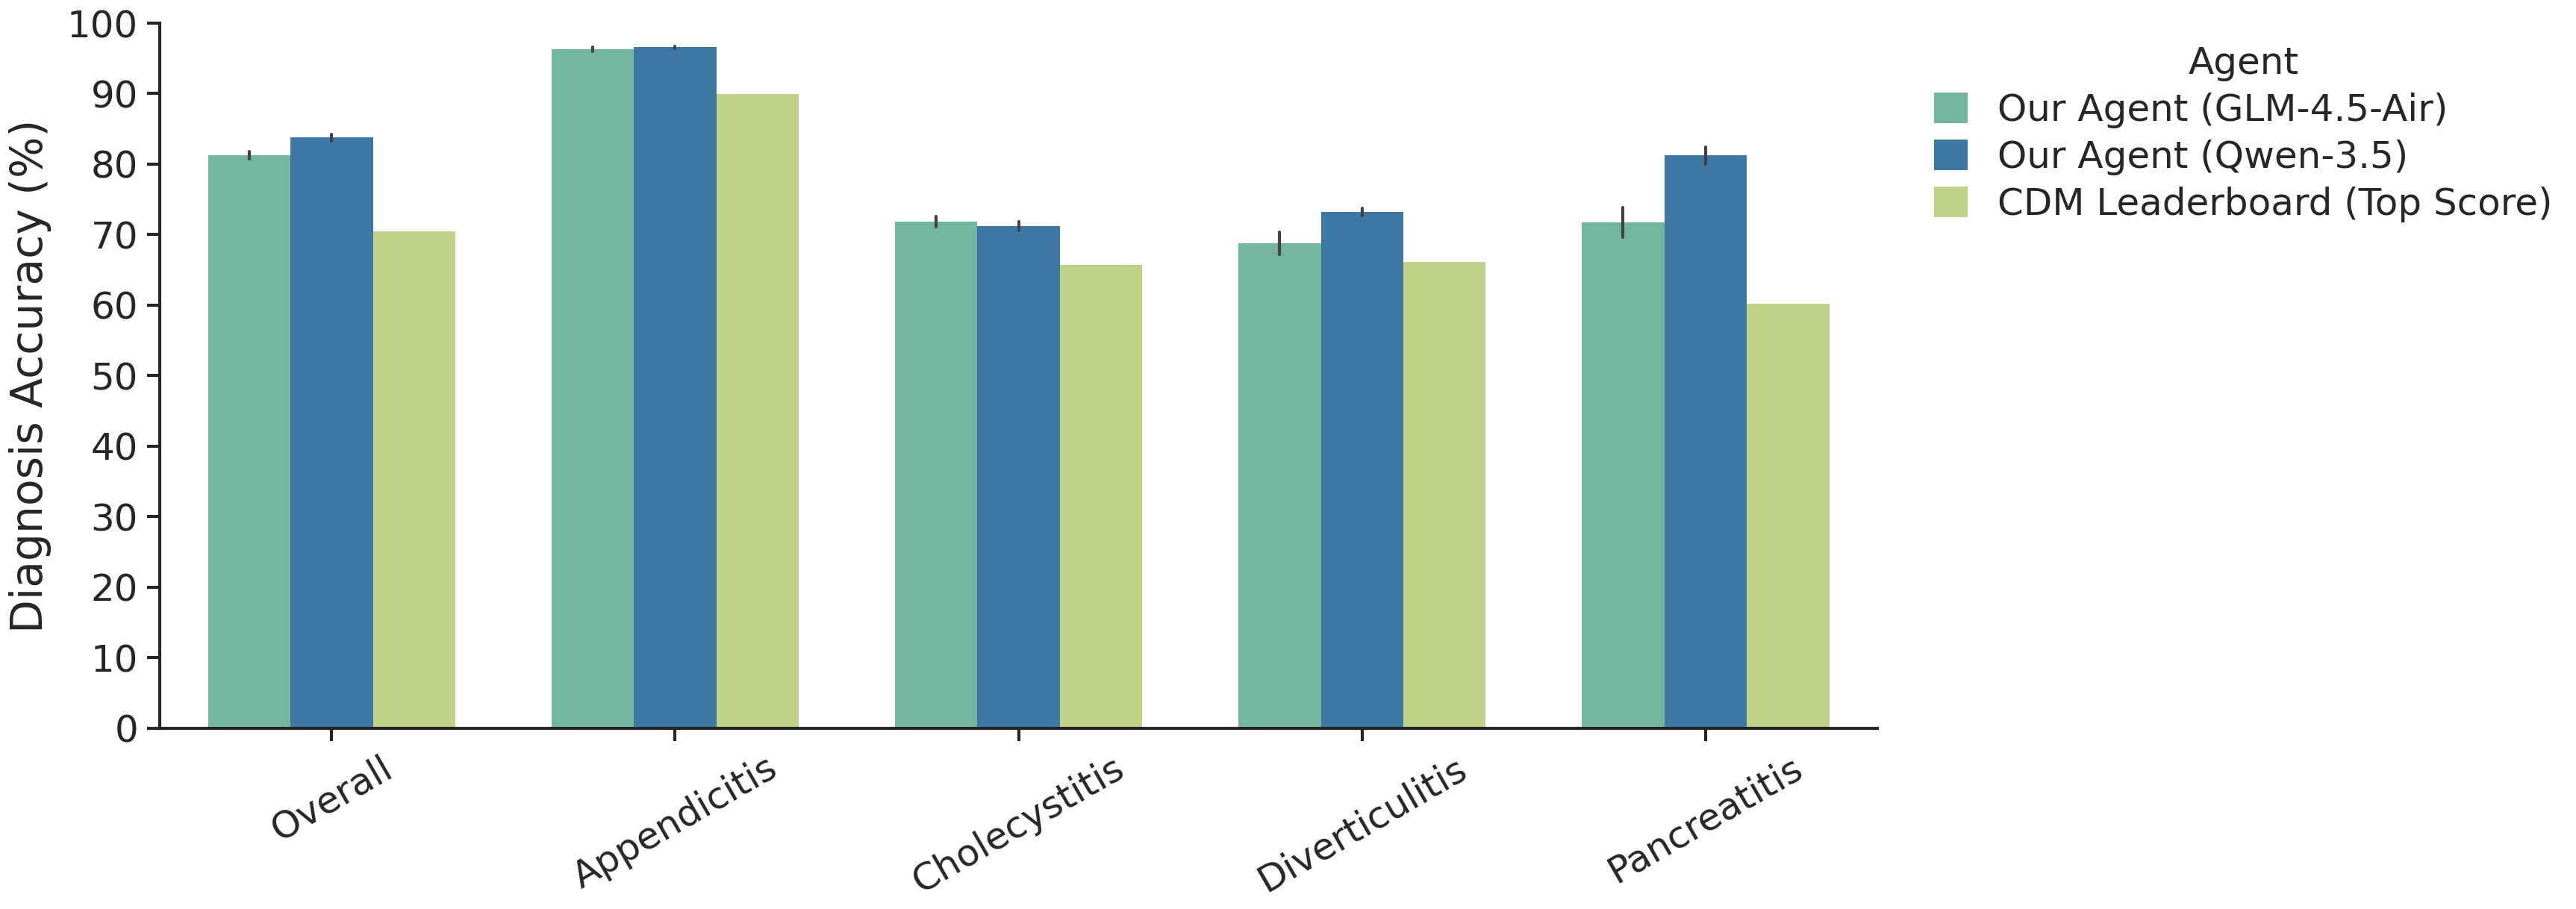

In [1]:
# vis_cdm_benchmark_comparison.py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import matplotlib.font_manager as fm
from matplotlib.ticker import MultipleLocator, FormatStrFormatter


# --- 1. Global style configuration ---
def setup_style(double_column: bool = True):
    if double_column:
        fig_w_in = 7.09 #*0.8 #* 0.7
        fig_h_in = 2.2 #*0.9#* 0.77
    else:
        fig_w_in = 3.46
        fig_h_in = 2.0

    sns.set_theme(style="white", context="paper", font_scale=1.0)

    plt.rcParams.update({
        "figure.figsize": (fig_w_in, fig_h_in),
        "figure.dpi": 600,
        "savefig.dpi": 600,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.02,

        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans", "Liberation Sans"],
        "pdf.fonttype": 42,
        "ps.fonttype": 42,

        "font.size": 7,
        "axes.labelsize": 7,
        "axes.titlesize": 7,
        "xtick.labelsize": 6,
        "ytick.labelsize": 6,
        "legend.fontsize": 6,
        "legend.title_fontsize": 6,

        "axes.spines.top": False,
        "axes.spines.right": False,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "xtick.major.width": 0.5,
        "ytick.major.width": 0.5,
        "xtick.minor.width": 0.4,
        "ytick.minor.width": 0.4,
        "xtick.major.size": 2.0,
        "ytick.major.size": 2.0,
        "xtick.minor.size": 1.5,
        "ytick.minor.size": 1.5,
        "axes.linewidth": 0.5,
        "patch.edgecolor": "none",
        "patch.linewidth": 0.0,

        "axes.grid": False,
        "figure.autolayout": False,
        "mathtext.default": "regular",
        "axes.titlepad": 3,
        "axes.labelpad": 2.5,
    })

setup_style(double_column=True)

# --- 2. Configuration section ---
# a. Define file and directory paths
# CSV file generated in Task 1.
GLM_AGENT_CSV_PATH = '/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/evaluation_logs/55_clean/cdm/cdm_benchmark_accuracies.csv'

QWEN_AGENT_CSV_PATH = '/mnt/bulk-uranus/lizhang/LiWorkSpace/data/evaluation/85/fuzzy_matching/cdm/cdm_benchmark_accuracies.csv'

# Directory for final figures.
PLOTS_OUTPUT_DIR = '/mnt/bulk-sirius/lizhang/LiWS/Medical_Llama_Agents/data/plots/cdm_benchmark/cdm_comparison'
os.makedirs(PLOTS_OUTPUT_DIR, exist_ok=True)

# --- 3. Data preparation ---

# a. CDM Leaderboard benchmark data
print("正在加载CDM Leaderboard基准数据...")
cdm_leaderboard_data = {
    'Dataset': ['Overall', 'Appendicitis', 'Cholecystitis', 'Diverticulitis', 'Pancreatitis'],
    'Accuracy': [70.5, 89.9, 65.7, 66.1, 60.2],
    'Model': 'CDM Leaderboard (Top Score)',
}
df_benchmark = pd.DataFrame(cdm_leaderboard_data)

# b. Load and process our model data
print(f"正在加载我们模型的数据...")
def load_agent_results(csv_path, model_name):
    df = pd.read_csv(csv_path)
    df = df.rename(columns={'dataset': 'Dataset', 'accuracy': 'Accuracy'})
    df['Model'] = model_name
    return df
try:
    df_glm_agent_runs = load_agent_results(
        GLM_AGENT_CSV_PATH,
        'Our Agent (GLM-4.5-Air)'
    )
    df_qwen_agent_runs = load_agent_results(
        QWEN_AGENT_CSV_PATH,
        'Our Agent (Qwen-3.5)'
    )
except FileNotFoundError:
    print(f"❌ 错误: 文件未找到")
    print("请先运行任务一的脚本 (process_cdm_results.py)。")
    exit()


# d. Add a Model identifier column to both DataFrames and rename fields
df_benchmark['Model'] = 'CDM Leaderboard (Top Score)'

df_plot = pd.concat(
    [df_glm_agent_runs, df_qwen_agent_runs, df_benchmark],
    ignore_index=True
)


# f. Sorting (unchanged).
dataset_order = ['Overall'] + sorted([d for d in df_plot['Dataset'].unique() if d != 'Overall'])
# df_plot['Dataset'] = pd.Categorical(df_plot['Dataset'], categories=dataset_order, ordered=True)
# df_plot = df_plot.sort_values(['Dataset', 'Model'])

# --- 4. Draw the chart ---
print("\n正在生成图表...")
fig, ax = plt.subplots()

# a. Basic settings ( Style)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False) # Remove the grid.
for spine in ["left", "bottom"]:
    ax.spines[spine].set_linewidth(0.5)

# b. Define colors and ordering
color_palette = {
    'Our Agent (GLM-4.5-Air)': '#66c2a4', #'#74bbde',
    'Our Agent (Qwen-3.5)': '#2c7bb6',
    'CDM Leaderboard (Top Score)': "#C6DF7A", #'#E595A4', #'#eda7a8',
}

model_order = [
    'Our Agent (GLM-4.5-Air)',
    'Our Agent (Qwen-3.5)',
    'CDM Leaderboard (Top Score)',
]

dataset_order = ['Overall'] + sorted([d for d in df_plot['Dataset'].unique() if d != 'Overall'])


# c. Draw bar charts using the original sd error bars
sns.barplot(
    data=df_plot,
    x='Dataset',
    y='Accuracy',
    hue='Model',
    palette=color_palette,
    hue_order=model_order,
    order=dataset_order,
    errorbar='sd', # <-- Key: use seaborn default standard-deviation error bars.
    capsize=0,
    err_kws={
        # 'color': 'gray', 
        'linewidth': 0.5
        },
    width=0.72,
    linewidth=0,
    edgecolor='none',
    ax=ax,
)


# --- 5. Style the chart ---
ax.tick_params(
    axis="both",
    which="major",
    width=0.5,
    length=2.0,
    direction="out",
    top=False,
    right=False,
    bottom=True,
    left=True,
    pad=1.5,
)
ax.set_xlabel('')
ax.set_ylabel('Diagnosis Accuracy (%)')

min_accuracy = df_plot['Accuracy'].min()
# ax.set_ylim(max(0, min_accuracy - 10), 100)
ax.set_ylim(0, 100)

ax.yaxis.set_major_locator(MultipleLocator(10))
ax.yaxis.set_major_formatter(FormatStrFormatter("%.0f"))

# plt.xticks(rotation=30, ha='right')
plt.xticks(rotation=30)

# Custom legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles=handles,
    labels=labels,
    title='Agent',
    bbox_to_anchor=(1.02, 1.0),
    loc='upper left',
    frameon=False,
    handlelength=0.9,
    handleheight=0.9,
    borderaxespad=0.2,
    labelspacing=0.3,
    columnspacing=0.8,
)

plt.tight_layout(rect=[0, 0, 0.84, 1]) # Reserve space for the external legend.

# --- 6. Save the figure ---
output_path_svg = os.path.join(PLOTS_OUTPUT_DIR, 'accuracy_comparison_vs_cdm.svg')
output_path_png = os.path.join(PLOTS_OUTPUT_DIR, 'accuracy_comparison_vs_cdm.png')
output_path_pdf = os.path.join(PLOTS_OUTPUT_DIR, 'accuracy_comparison_vs_cdm.pdf')

plt.savefig(output_path_svg, format="svg", bbox_inches='tight')
plt.savefig(output_path_png, format="png", bbox_inches='tight')
plt.savefig(output_path_pdf, format="pdf", bbox_inches='tight')

print(f"\n✅ 基准对比图已成功保存。")
plt.show()